# Network Mapping

Map parcel-level modality attention summaries onto Schaefer/Yeo networks. This notebook loads atlas outputs from `attn_map_analysis/results/<subject>/<run_name>/`, summarizes relative modality attention by Schaefer network, and visualizes network-level modality profiles on heatmaps, atlas projections, and row-aligned trend plots.


In [138]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.font_manager as fm
import nibabel as nib
from nilearn import datasets, plotting
import seaborn as sns

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="whitegrid", context="paper", font="Times New Roman")

REPO_ROOT = Path.cwd()
if REPO_ROOT.name != "multimodal_encoder":
    REPO_ROOT = Path("/engram/nklab/pf2477/multimodal_encoder")

RESULT_ROOT = REPO_ROOT / "attn_map_analysis" / "results"
FIGURE_ROOT = REPO_ROOT / "attn_map_analysis" / "figures"
TABLE_ROOT = REPO_ROOT / "attn_map_analysis" / "tables"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

RUNS = (
    (1, "04-07-2026-16-09", "dino_whisper_llama", "parcels"),
    (2, "04-07-2026-16-13", "dino_whisper_llama", "parcels"),
    (3, "04-08-2026-00-52", "dino_whisper_llama", "parcels"),
    (5, "04-08-2026-00-55", "dino_whisper_llama", "parcels"),
    (1, "04-08-2026-23-43", "dino_whisper_llama", "voxels"),
    (2, "04-08-2026-23-48", "dino_whisper_llama", "voxels"),
    (3, "04-08-2026-23-57", "dino_whisper_llama", "voxels"),
    (5, "04-12-2026-19-49", "dino_whisper_llama", "voxels"),
    (1, "04-18-2026-01-08", "videmae_wav2vec_deberta", "parcels"),
    (2, "04-18-2026-01-14", "videmae_wav2vec_deberta", "parcels"),
    (3, "04-18-2026-22-20", "videmae_wav2vec_deberta", "parcels"),
    (5, "04-18-2026-22-22", "videmae_wav2vec_deberta", "parcels"),
    (1, "04-19-2026-02-08", "videmae_wav2vec_deberta", "voxels"),
    (2, "04-19-2026-02-10", "videmae_wav2vec_deberta", "voxels"),
    (3, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
    (5, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
)

MODALITY_COLORS = {
    "video": "#4285F4",
    "audio": "#DB4437",
    "text": "#F4B400",
}
NEUTRAL_NETWORK_COLOR = "#D0D0D0"
PREFERENCE_TOP_TOKEN_FRACTION = 0.25
SELECTED_RUN_INDEX = 8
SELECTED_RUN_KEY = None


## Load Runs

`relative_{modality}_centered` is a bounded percent scale centered against each modality's parcel-wise baseline. Preference/selectivity use top-token fractions when the suffixed top-token output exists, falling back to the unsuffixed alias and then to modality-sum fractions.


In [139]:
def load_json(path):
    with Path(path).open("r") as f:
        return json.load(f)


def normalized_entropy(p, axis=-1, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = p / np.clip(p.sum(axis=axis, keepdims=True), eps, None)
    ent = -(p * np.log(np.clip(p, eps, None))).sum(axis=axis)
    return ent / np.log(p.shape[axis])


def top_token_fraction_suffix(fraction):
    percent = 100.0 * float(fraction)
    if np.isclose(percent, round(percent)):
        return f"top{int(round(percent)):02d}pct"
    compact = f"{float(fraction):.6g}".replace(".", "p")
    return f"frac{compact}"


def normalize_run_specs(run_specs):
    for spec in run_specs:
        if isinstance(spec, dict):
            yield {
                "subject_id": int(spec["subject_id"]),
                "run_name": str(spec["run_name"]),
                "backbones": str(spec.get("backbones", spec.get("backbone", "unknown"))),
                "readout": str(spec.get("readout", "unknown")),
            }
        else:
            if len(spec) != 4:
                raise ValueError(f"Expected RUNS entries as (subject_id, run_name, backbones, readout), got {spec}")
            subject_id, run_name, backbones, readout = spec
            yield {
                "subject_id": int(subject_id),
                "run_name": str(run_name),
                "backbones": str(backbones),
                "readout": str(readout),
            }


def make_run_key(subject_id, run_name, backbones, readout):
    return f"sub-{int(subject_id):02d}_{backbones}_{readout}_{run_name}"


def load_run(subject_id, run_name, backbones="unknown", readout="unknown"):
    run_dir = RESULT_ROOT / str(subject_id) / run_name
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)

    metadata = load_json(run_dir / "metadata.json")
    qc = load_json(run_dir / "quality_control.json")
    modalities = list(metadata["modalities"])
    run_key = make_run_key(subject_id, run_name, backbones, readout)

    norm = np.load(run_dir / "parcel_modality_attn_norm.npy")
    raw = np.load(run_dir / "parcel_modality_attn_raw.npy")
    query_to_parcel = np.load(run_dir / "query_to_parcel.npy")

    top_suffix = top_token_fraction_suffix(PREFERENCE_TOP_TOKEN_FRACTION)
    top_mean_path = run_dir / f"parcel_modality_attn_top_token_mean_{top_suffix}.npy"
    top_fraction_path = run_dir / f"parcel_modality_attn_top_token_fraction_{top_suffix}.npy"
    top_source = top_suffix
    if not top_mean_path.exists() or not top_fraction_path.exists():
        top_mean_path = run_dir / "parcel_modality_attn_top_token_mean.npy"
        top_fraction_path = run_dir / "parcel_modality_attn_top_token_fraction.npy"
        top_source = "primary_alias"

    top_token_mean = np.load(top_mean_path) if top_mean_path.exists() else None
    top_token_fraction = np.load(top_fraction_path) if top_fraction_path.exists() else None

    norm_fraction = norm / np.clip(norm.sum(axis=1, keepdims=True), 1e-12, None)
    raw_fraction = raw / np.clip(raw.sum(axis=1, keepdims=True), 1e-12, None)
    preference_fraction = top_token_fraction if top_token_fraction is not None else norm_fraction
    preference_score_source = (
        f"top_token_fraction_{top_source}" if top_token_fraction is not None else "modality_sum_fraction"
    )

    winner_index = preference_fraction.argmax(axis=1).astype(int)
    sorted_fraction = np.sort(preference_fraction, axis=1)
    entropy = normalized_entropy(preference_fraction)

    parcel_df = pd.DataFrame({
        "run_key": run_key,
        "subject_id": subject_id,
        "run_name": run_name,
        "backbones": backbones,
        "readout": readout,
        "parcel_id": query_to_parcel.astype(int),
        "winner_code": winner_index,
        "winner_modality": [modalities[i] for i in winner_index],
        "winner_margin": sorted_fraction[:, -1] - sorted_fraction[:, -2],
        "modality_entropy": entropy,
        "modality_selectivity": 1.0 - entropy,
    })

    for i, modality in enumerate(modalities):
        parcel_df[f"{modality}_norm"] = norm[:, i]
        parcel_df[f"{modality}_raw"] = raw[:, i]
        parcel_df[f"{modality}_fraction"] = norm_fraction[:, i]
        parcel_df[f"{modality}_raw_fraction"] = raw_fraction[:, i]

        baseline = norm_fraction[:, i].mean()
        centered = norm_fraction[:, i] - baseline
        parcel_df[f"relative_{modality}_centered"] = np.where(
            centered >= 0,
            100 * centered / np.clip(1.0 - baseline, 1e-12, None),
            100 * centered / np.clip(baseline, 1e-12, None),
        )

    return {
        "run_key": run_key,
        "subject_id": subject_id,
        "run_name": run_name,
        "backbones": backbones,
        "readout": readout,
        "run_dir": run_dir,
        "metadata": metadata,
        "qc": qc,
        "modalities": modalities,
        "norm": norm,
        "raw": raw,
        "norm_fraction": norm_fraction,
        "raw_fraction": raw_fraction,
        "top_token_mean": top_token_mean,
        "top_token_fraction": top_token_fraction,
        "preference_fraction": preference_fraction,
        "preference_score_source": preference_score_source,
        "query_to_parcel": query_to_parcel,
        "parcel_df": parcel_df,
    }


run_specs = list(normalize_run_specs(RUNS))
run_list = [load_run(**spec) for spec in run_specs]
runs = {run["run_key"]: run for run in run_list}
DEFAULT_RUN_KEY = run_list[0]["run_key"]
parcel_df = pd.concat([run["parcel_df"] for run in run_list], ignore_index=True)

run_summary = pd.DataFrame([
    {
        "run_key": run["run_key"],
        "subject_id": run["subject_id"],
        "run_name": run["run_name"],
        "backbones": run["backbones"],
        "readout": run["readout"],
        "samples": run["qc"]["num_samples_analyzed"],
        "queries": run["metadata"]["num_queries"],
        "attention_head_aggregation": run["metadata"].get("attention_head_aggregation", "unknown"),
        "preference_score_source": run["preference_score_source"],
        "qc_ok": run["qc"]["attn_sum_axis_last_within_tolerance"],
    }
    for run in run_list
])

run_summary


,run_key,subject_id,run_name,backbones,readout,samples,queries,attention_head_aggregation,preference_score_source,qc_ok
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,True
1,sub-02_dino_whisper_llama_parcels_04-07-2026-1...,2,04-07-2026-16-13,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,True
2,sub-03_dino_whisper_llama_parcels_04-08-2026-0...,3,04-08-2026-00-52,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,True
3,sub-05_dino_whisper_llama_parcels_04-08-2026-0...,5,04-08-2026-00-55,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,True
4,sub-01_dino_whisper_llama_voxels_04-08-2026-23-43,1,04-08-2026-23-43,dino_whisper_llama,voxels,4875,1000,mean,top_token_fraction_top25pct,True
5,sub-02_dino_whisper_llama_voxels_04-08-2026-23-48,2,04-08-2026-23-48,dino_whisper_llama,voxels,4883,1000,mean,top_token_fraction_top25pct,True
6,sub-03_dino_whisper_llama_voxels_04-08-2026-23-57,3,04-08-2026-23-57,dino_whisper_llama,voxels,4871,1000,mean,top_token_fraction_top25pct,True
7,sub-05_dino_whisper_llama_voxels_04-12-2026-19-49,5,04-12-2026-19-49,dino_whisper_llama,voxels,4883,1000,mean,top_token_fraction_top25pct,True
8,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,4863,1000,mean,top_token_fraction_top25pct,True
9,sub-02_videmae_wav2vec_deberta_parcels_04-18-2...,2,04-18-2026-01-14,videmae_wav2vec_deberta,parcels,4863,1000,mean,top_token_fraction_top25pct,True


## Schaefer Labels

Load Schaefer-1000 labels and preserve the network order from the atlas. `schaefer_labels` is the authoritative network order for all heatmaps and profile plots.


In [140]:
def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")
    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=17, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )
    raw_labels = [as_str(label) for label in atlas.labels if as_str(label) != "Background"]

    network_order = []
    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        parsed = parse_schaefer_label(label)
        if parsed["network"] not in network_order:
            network_order.append(parsed["network"])
        rows.append({"parcel_id": parcel_id, **parsed})

    return pd.DataFrame(rows), network_order


labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=17)
parcel_roi_df = parcel_df.merge(labels_df, on="parcel_id", how="left")
parcel_roi_df.to_csv(TABLE_ROOT / "parcel_modality_attention_with_schaefer_labels.csv", index=False)
labels_df.head()


[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018


,parcel_id,schaefer_name,hemi,network,region,parcel_index_in_lut
0,1,17Networks_LH_VisCent_Striate_1,LH,VisCent,Striate,1
1,2,17Networks_LH_VisCent_Striate_2,LH,VisCent,Striate,2
2,3,17Networks_LH_VisCent_Striate_3,LH,VisCent,Striate,3
3,4,17Networks_LH_VisCent_Striate_4,LH,VisCent,Striate,4
4,5,17Networks_LH_VisCent_ExStr_1,LH,VisCent,ExStr,1


## Helpers

In [141]:
FMRI_ROOT = Path("/engram/nklab/datasets/algonauts_2025.competitors/fmri")
SUBJECT_ATLAS = {
    1: "sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    2: "sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    3: "sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    5: "sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
}


def run_label(run):
    return f"sub-{run['subject_id']:02d} | {run['backbones']} | {run['readout']}"


def file_label(run):
    return f"sub-{run['subject_id']:02d}_{run['backbones']}_{run['readout']}_{run['run_name']}"


def resolve_selected_run():
    if SELECTED_RUN_KEY is not None:
        return runs[str(SELECTED_RUN_KEY)]
    return run_list[int(SELECTED_RUN_INDEX)]


def load_subject_schaefer(subject_id):
    path = FMRI_ROOT / SUBJECT_ATLAS[int(subject_id)]
    img = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    return img, data


def parcel_values_to_img(parcel_values, subject_id, background_to_nan=True):
    parcel_values = np.asarray(parcel_values, dtype=np.float32)
    if parcel_values.shape != (1000,):
        raise ValueError(f"Expected parcel_values shape (1000,), got {parcel_values.shape}")

    atlas_img, atlas_data = load_subject_schaefer(subject_id)
    out = np.full(atlas_data.shape, np.nan if background_to_nan else 0.0, dtype=np.float32)
    for parcel_id in range(1, 1001):
        out[atlas_data == parcel_id] = parcel_values[parcel_id - 1]
    return nib.Nifti1Image(out, affine=atlas_img.affine, header=atlas_img.header)


def set_nilearn_display_background(display, fig, facecolor="white"):
    fig.patch.set_facecolor(facecolor)
    for axis in display.axes.values():
        mpl_ax = getattr(axis, "ax", axis)
        mpl_ax.set_facecolor(facecolor)
    cbar = getattr(display, "_cbar", None)
    if cbar is not None:
        cbar.ax.set_facecolor(facecolor)
    return cbar


def save_display(display, fig, out_file=None, dpi=250):
    if out_file is not None:
        fig.savefig(str(out_file), dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plotting.show()
    return display


def plot_categorical_parcel_labels(subject_id, parcel_codes, code_labels, code_colors, title=None, out_file=None):
    parcel_codes = np.asarray(parcel_codes, dtype=np.float32)
    if parcel_codes.shape != (1000,):
        raise ValueError(f"Expected parcel_codes shape (1000,), got {parcel_codes.shape}")

    base_img = parcel_values_to_img(np.zeros(parcel_codes.shape, dtype=np.float32), subject_id, background_to_nan=False)
    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        base_img,
        display_mode="lyrz",
        title=title,
        colorbar=False,
        plot_abs=False,
        threshold=1.0,
        vmin=0.0,
        vmax=1.0,
        black_bg=False,
        figure=fig,
    )
    set_nilearn_display_background(display, fig)

    for code, _label in code_labels:
        mask = parcel_codes == float(code)
        if not np.any(mask):
            continue
        values = np.full(parcel_codes.shape, np.nan, dtype=np.float32)
        values[mask] = 1.0
        display.add_overlay(
            parcel_values_to_img(values, subject_id),
            cmap=ListedColormap([code_colors[code]]),
            threshold=0.5,
            vmin=0.0,
            vmax=1.0,
            colorbar=False,
        )

    return save_display(display, fig, out_file=out_file)


## Network Summaries

In [142]:
network_order = list(schaefer_labels)
modalities = list(run_list[0]["modalities"])
run_id_cols = ["run_key", "subject_id", "run_name", "backbones", "readout"]
fraction_cols = [f"{modality}_fraction" for modality in modalities]
relative_cols = [f"relative_{modality}_centered" for modality in modalities]

network_summary = (
    parcel_roi_df
    .groupby(run_id_cols + ["network"], as_index=False)[
        fraction_cols + relative_cols + ["modality_entropy", "modality_selectivity"]
    ]
    .mean()
)
network_summary["network"] = pd.Categorical(network_summary["network"], network_order, ordered=True)
network_summary = network_summary.sort_values(run_id_cols + ["network"])
network_summary.to_csv(TABLE_ROOT / "network_modality_attention.csv", index=False)

hemi_network_summary = (
    parcel_roi_df
    .groupby(run_id_cols + ["hemi", "network"], as_index=False)[fraction_cols + ["modality_selectivity"]]
    .mean()
)
hemi_network_summary.to_csv(TABLE_ROOT / "hemi_network_modality_attention.csv", index=False)

network_summary.head()


,run_key,subject_id,run_name,backbones,readout,network,video_fraction,audio_fraction,text_fraction,relative_video_centered,relative_audio_centered,relative_text_centered,modality_entropy,modality_selectivity
15,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,VisCent,0.316308,0.527935,0.155758,10.182037,-6.043898,-23.356152,0.884928,0.115072
16,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,VisPeri,0.344154,0.514923,0.140923,14.063213,-8.437901,-30.289879,0.882380,0.117620
12,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,SomMotA,0.225841,0.594106,0.180053,-12.484509,7.950366,-13.085692,0.834969,0.165031
13,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,SomMotB,0.237891,0.558610,0.203499,-5.072728,-0.018216,-4.975092,0.881474,0.118526
6,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,DorsAttnA,0.246105,0.549128,0.204767,-2.159600,-2.025219,-4.662086,0.892294,0.107706


## Selected Run Network Heatmap

The heatmap summarizes mean relative attention by Schaefer network and modality. Positive values indicate above-baseline relative attention for that modality within a network; negative values indicate relative suppression.


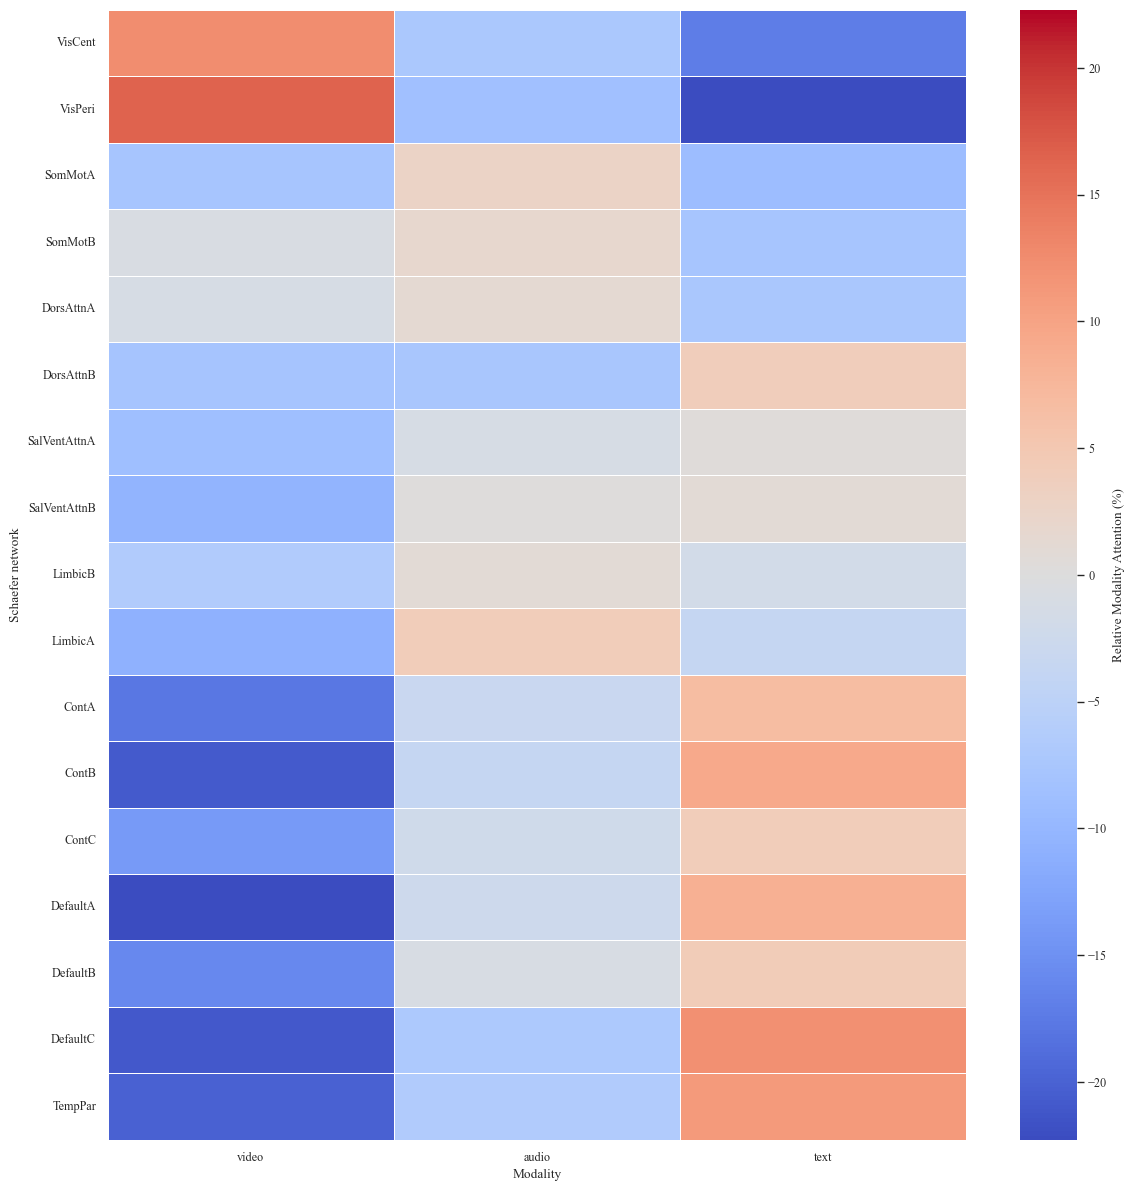

,run_key,subject_id,run_name,backbones,readout,network,modality,mean_relative_attention,median_relative_attention,std,sem,n_parcels,n_finite
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,video,12.432081,13.373862,7.477776,0.875207,73,73
1,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,audio,-7.285640,-7.539075,6.815859,0.797736,73,73
2,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,text,-17.152562,-15.967912,13.053768,1.527828,73,73
3,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisPeri,video,16.442123,16.786320,6.766581,0.866372,61,61
4,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisPeri,audio,-8.596034,-8.844043,6.267766,0.802505,61,61


In [143]:
run = resolve_selected_run()
network_order = list(schaefer_labels)
modalities = list(run["modalities"])
relative_cols = [f"relative_{modality}_centered" for modality in modalities]

run_network_df = run["parcel_df"].merge(labels_df, on="parcel_id", how="left")
missing_network = int(run_network_df["network"].isna().sum())
if missing_network:
    raise ValueError(f"Missing Schaefer network labels for {missing_network} parcels.")

records = []
for network in network_order:
    parcel_mask = run_network_df["network"].to_numpy() == network
    n_parcels = int(parcel_mask.sum())
    for modality, col in zip(modalities, relative_cols):
        values = run_network_df.loc[parcel_mask, col].to_numpy(dtype=float)
        finite = np.isfinite(values)
        n_finite = int(finite.sum())
        records.append({
            "run_key": run["run_key"],
            "subject_id": run["subject_id"],
            "run_name": run["run_name"],
            "backbones": run["backbones"],
            "readout": run["readout"],
            "network": network,
            "modality": modality,
            "mean_relative_attention": np.nanmean(values) if n_finite else np.nan,
            "median_relative_attention": np.nanmedian(values) if n_finite else np.nan,
            "std": np.nanstd(values, ddof=1) if n_finite > 1 else np.nan,
            "sem": np.nanstd(values, ddof=1) / np.sqrt(n_finite) if n_finite > 1 else np.nan,
            "n_parcels": n_parcels,
            "n_finite": n_finite,
        })

network_overlap_df = pd.DataFrame(records)
network_overlap_df["network"] = pd.Categorical(network_overlap_df["network"], network_order, ordered=True)
network_overlap_df["modality"] = pd.Categorical(network_overlap_df["modality"], modalities, ordered=True)
network_overlap_df = network_overlap_df.sort_values(["network", "modality"])
network_overlap_df.to_csv(TABLE_ROOT / f"{file_label(run)}_network_relative_attention.csv", index=False)

heatmap_df = (
    network_overlap_df
    .pivot(index="network", columns="modality", values="mean_relative_attention")
    .loc[network_order, modalities]
)
heatmap_values = heatmap_df.to_numpy(dtype=float)
vmax = np.nanpercentile(np.abs(heatmap_values), 98)
vmax = 1.0 if not np.isfinite(vmax) or np.isclose(vmax, 0) else float(vmax)

fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=False,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relative Modality Attention (%)"},
    ax=ax,
)
ax.set_xlabel("Modality")
ax.set_ylabel("Schaefer network")
fig.tight_layout()
fig.savefig(
    FIGURE_ROOT / f"{file_label(run)}_network_relative_attention_heatmap.pdf",
    dpi=250,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()

network_overlap_df.head()


## Network Color Atlas

Networks with positive heatmap values are colored by modality. If two or three modalities are positive in the same network, their RGB colors are averaged. Networks with no positive modality are gray.


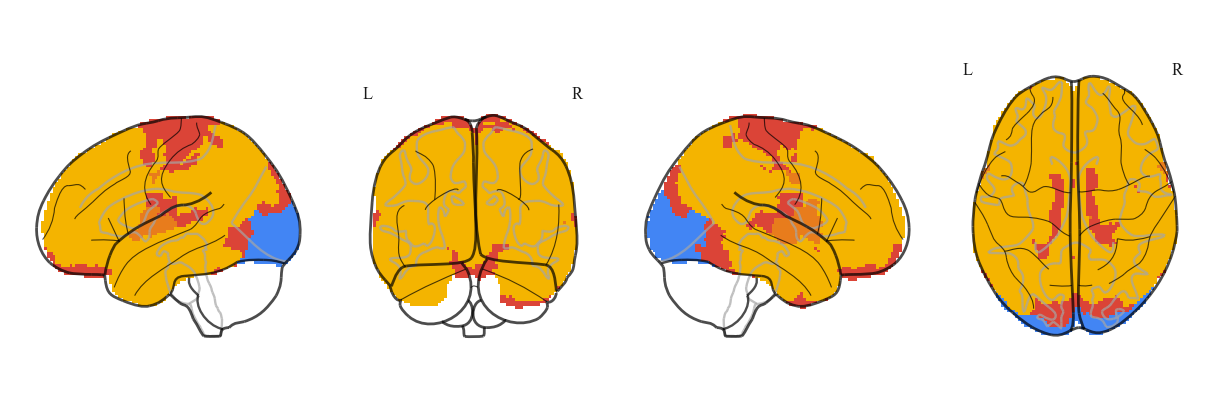

,run_key,subject_id,run_name,backbones,readout,network,positive_modalities,network_color,video_mean_relative_attention,audio_mean_relative_attention,text_mean_relative_attention
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisCent,video,#4285f4,12.432081,-7.285640,-17.152562
1,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,VisPeri,video,#4285f4,16.442123,-8.596034,-22.832057
2,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SomMotA,audio,#db4437,-7.676015,2.670393,-9.151707
3,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SomMotB,audio,#db4437,-0.840772,1.742451,-7.686915
4,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,DorsAttnA,audio,#db4437,-1.198573,1.250215,-7.371233
5,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,DorsAttnB,text,#f4b400,-7.904793,-7.540189,3.991104
6,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SalVentAttnA,text,#f4b400,-8.747277,-1.154369,0.432688
7,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SalVentAttnB,audio+text,#e87c1c,-10.507162,0.280940,0.955111
8,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,LimbicB,audio,#db4437,-6.597268,0.959695,-1.766166
9,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,LimbicA,audio,#db4437,-10.931061,4.073697,-3.712468


In [144]:
modality_rgb = {
    modality: np.asarray(mcolors.to_rgb(MODALITY_COLORS[modality]), dtype=float)
    for modality in modalities
}
network_code_by_name = {network: code for code, network in enumerate(network_order)}
network_colors = {}
network_labels_for_legend = []
network_color_records = []

for network in network_order:
    row = heatmap_df.loc[network, modalities].astype(float)
    positive_modalities = [
        modality for modality in modalities
        if np.isfinite(row[modality]) and row[modality] > 0
    ]
    if positive_modalities:
        rgb = np.mean([modality_rgb[modality] for modality in positive_modalities], axis=0)
        color = mcolors.to_hex(np.clip(rgb, 0, 1))
        blend_label = "+".join(positive_modalities)
    else:
        color = NEUTRAL_NETWORK_COLOR
        blend_label = "none positive"

    code = network_code_by_name[network]
    network_colors[code] = color
    network_labels_for_legend.append((code, f"{network}: {blend_label}"))
    network_color_records.append({
        "run_key": run["run_key"],
        "subject_id": run["subject_id"],
        "run_name": run["run_name"],
        "backbones": run["backbones"],
        "readout": run["readout"],
        "network": network,
        "positive_modalities": blend_label,
        "network_color": color,
        **{f"{modality}_mean_relative_attention": float(row[modality]) for modality in modalities},
    })

network_color_df = pd.DataFrame(network_color_records)
network_color_df.to_csv(TABLE_ROOT / f"{file_label(run)}_network_positive_modality_blend_colors.csv", index=False)

parcel_network_codes = np.full(1000, np.nan, dtype=np.float32)
for row in labels_df.itertuples(index=False):
    if row.network in network_code_by_name:
        parcel_network_codes[int(row.parcel_id) - 1] = float(network_code_by_name[row.network])

network_blend_display = plot_categorical_parcel_labels(
    run["subject_id"],
    parcel_network_codes,
    code_labels=network_labels_for_legend,
    code_colors=network_colors,
    title=None,
    out_file=FIGURE_ROOT / f"{file_label(run)}_network_positive_modality_blend_glass.pdf",
)

network_color_df


## Modality Network Profiles

Three row-aligned subplots show modality-specific relative attention trends across Schaefer networks. The dashed zero line marks no relative preference; values above zero indicate preferential attention and values below zero indicate relative suppression.


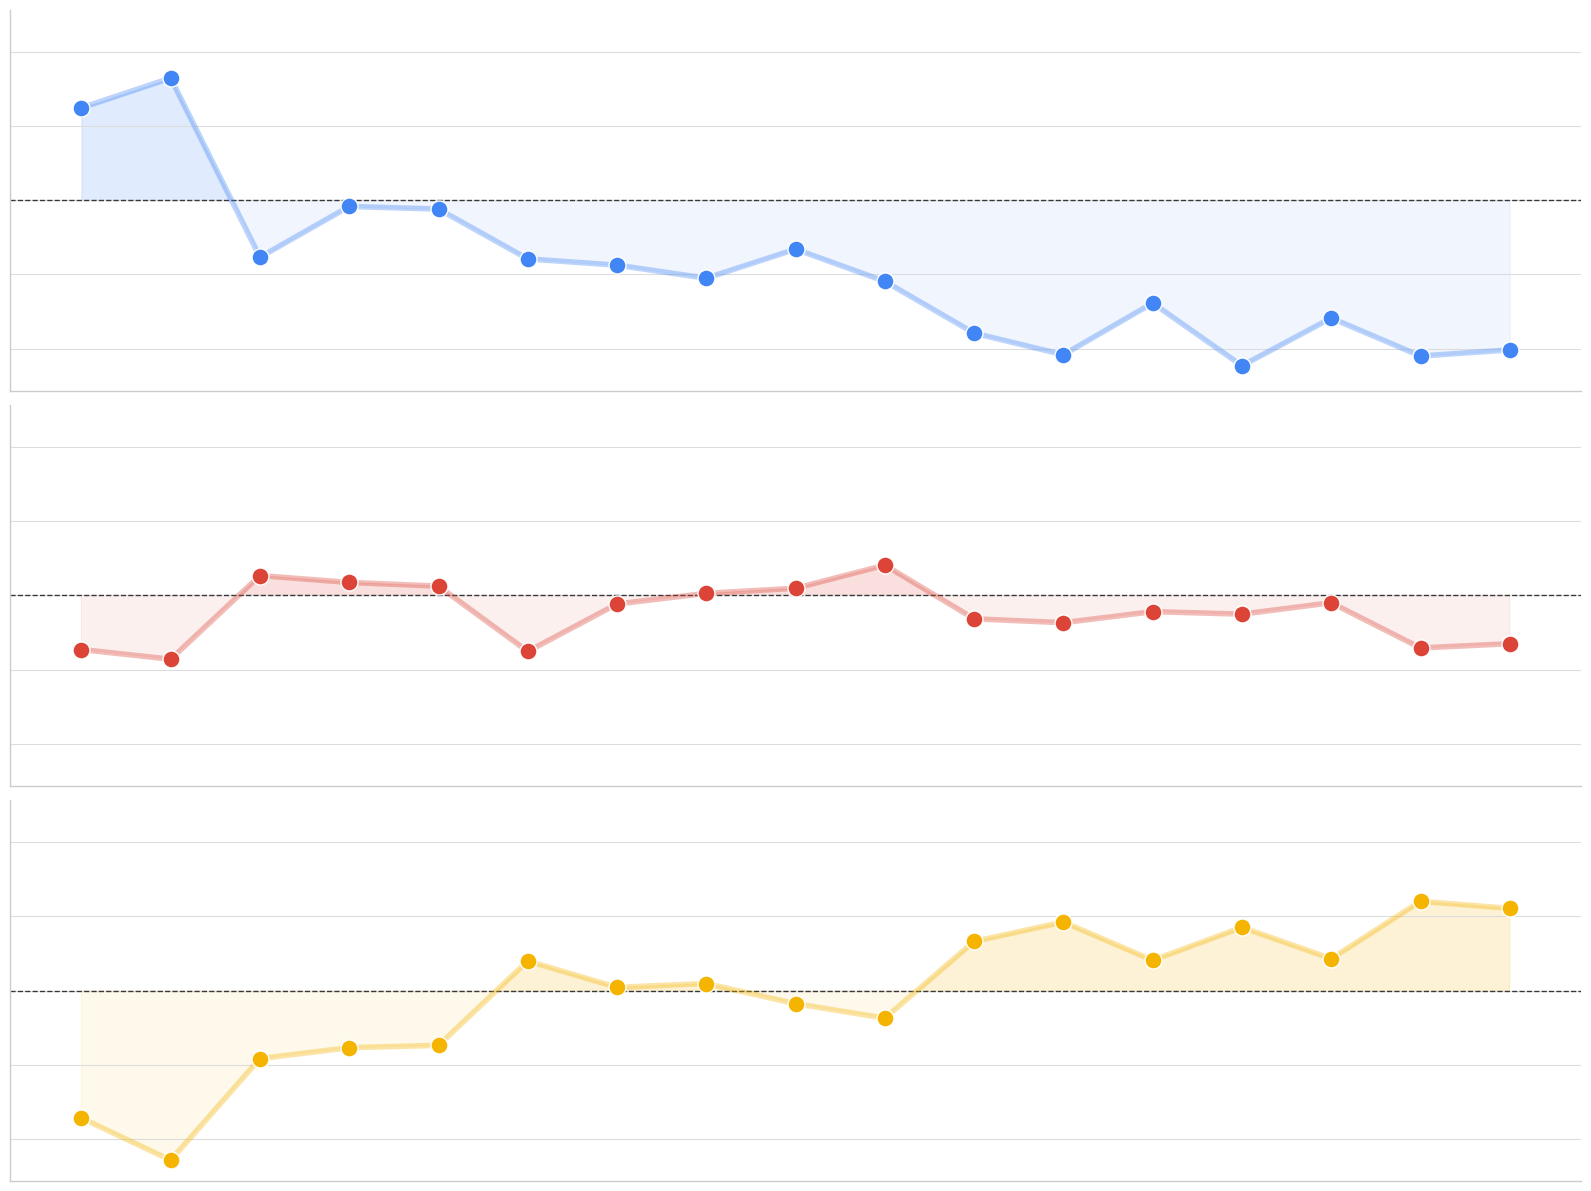

In [145]:
profile_df = heatmap_df.loc[network_order, modalities]
x = np.arange(len(network_order), dtype=float)

fig, axes = plt.subplots(
    nrows=len(modalities),
    ncols=1,
    # figsize=(0.84 * len(network_order), 2.1 * len(modalities)),
    figsize=(16 , 12),
    sharex=True,
    sharey=True,
    facecolor="white",
)
axes = np.atleast_1d(axes)

finite_values = profile_df.to_numpy(dtype=float)
y_lim = np.nanpercentile(np.abs(finite_values), 98)
y_lim = 1.0 if not np.isfinite(y_lim) or np.isclose(y_lim, 0) else float(y_lim)
y_lim *= 1.15

for ax, modality in zip(axes, modalities):
    y = profile_df[modality].to_numpy(dtype=float)
    finite = np.isfinite(y)
    color = MODALITY_COLORS[modality]

    ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75, zorder=1)
    ax.plot(x[finite], y[finite], color=color, alpha=0.35, linewidth=4, zorder=2)
    ax.scatter(x[finite], y[finite], color=color, edgecolor="white", linewidth=1, s=150, zorder=3)
    ax.fill_between(x, 0, y, where=np.isfinite(y) & (y >= 0), color=color, alpha=0.16, interpolate=True, zorder=0)
    ax.fill_between(x, 0, y, where=np.isfinite(y) & (y < 0), color=color, alpha=0.08, interpolate=True, zorder=0)

    ax.set_ylim(-y_lim, y_lim)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

axes[-1].set_xticks([])
fig.tight_layout()
fig.savefig(
    FIGURE_ROOT / f"{file_label(run)}_modality_network_profiles.pdf",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()


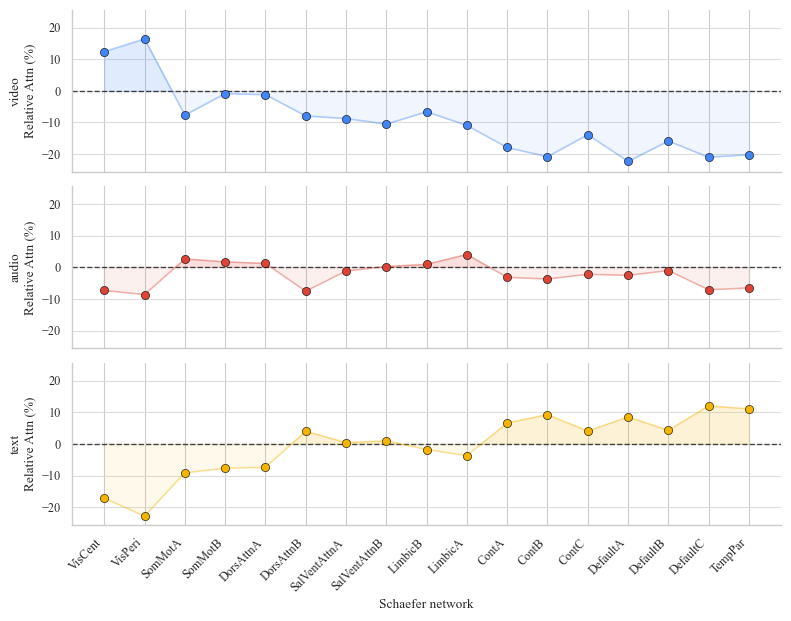

In [146]:
# Modality-specific network profiles: row-aligned trend plots
# This cell uses network_overlap_df from the Schaefer-network overlap heatmap cell.

if "network_overlap_df" not in globals():
    raise NameError("Run the Schaefer-network overlap heatmap cell before this profile plot cell.")

profile_df = (
    network_overlap_df
    .pivot(index="network", columns="modality", values="mean_relative_attention")
    .loc[network_order, modalities]
)
x = np.arange(len(network_order), dtype=float)

fig, axes = plt.subplots(
    nrows=len(modalities),
    ncols=1,
    figsize=(max(8.0, 0.42 * len(network_order)), 2.1 * len(modalities)),
    sharex=True,
    sharey=True,
    facecolor="white",
)
axes = np.atleast_1d(axes)

finite_values = profile_df.to_numpy(dtype=float)
y_lim = np.nanpercentile(np.abs(finite_values), 98)
y_lim = 1.0 if not np.isfinite(y_lim) or np.isclose(y_lim, 0) else float(y_lim)
y_lim *= 1.15

for ax, modality in zip(axes, modalities):
    y = profile_df[modality].to_numpy(dtype=float)
    finite = np.isfinite(y)
    color = MODALITY_COLORS[modality]

    ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.plot(x[finite], y[finite], color=color, alpha=0.35, linewidth=1.2)
    ax.scatter(x[finite], y[finite], color=color, edgecolor="black", linewidth=0.4, s=35, zorder=3)

    ax.fill_between(x, 0, y, where=np.isfinite(y) & (y >= 0), color=color, alpha=0.16, interpolate=True)
    ax.fill_between(x, 0, y, where=np.isfinite(y) & (y < 0), color=color, alpha=0.08, interpolate=True)
    ax.set_ylabel(f"{modality}\nRelative Attn (%)")
    ax.set_ylim(-y_lim, y_lim)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(network_order, rotation=45, ha="right")
axes[-1].set_xlabel("Schaefer network")
# fig.suptitle(f"{run_label(run)} modality-specific network profiles", y=1.02)
fig.tight_layout()
fig.savefig(
    FIGURE_ROOT / f"{file_label(run)}_modality_network_profiles.pdf",
    dpi=250,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()
